# Test de différentes interpolations

In [27]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt


df = pd.read_csv("../data/data_02923X0007_F.csv", sep=";")

df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

df['niveau_nappe_eau'] = pd.to_numeric(df['niveau_nappe_eau'], errors='coerce')

## Interpolation linéaire

Remarques : Déjà utilisé par Ethienne.

In [28]:
df['niveau_interp_linear'] = df['niveau_nappe_eau'].interpolate(method='linear', limit_direction='both')

## Interpolation spline cubique

Remarques : Formes interescente, à creser.

In [29]:
x = np.arange(len(df))
y = df['niveau_nappe_eau'].values
mask = ~np.isnan(y)

f_cubic = interp1d(x[mask], y[mask], kind='cubic', fill_value="extrapolate")
df['niveau_interp_cubic'] = f_cubic(x)

## Polynômes de degré n

Remarques :
C'est pas très bon et en soit je pense qu'une ia marchera bien mieux pour combler les données qui manque

In [ ]:
x = np.arange(len(df))
y = df['niveau_nappe_eau'].values

mask = ~np.isnan(y)
x_known = x[mask]
y_known = y[mask]

n_degree = 40
coeffs = np.polyfit(x_known, y_known, deg=n_degree)

poly_func = np.poly1d(coeffs)

df['niveau_poly'] = poly_func(x)

C:\Users\tronn\AppData\Local\Temp\ipykernel_4208\3755160366.py:9: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_known, y_known, deg=n_degree)


## Resultat

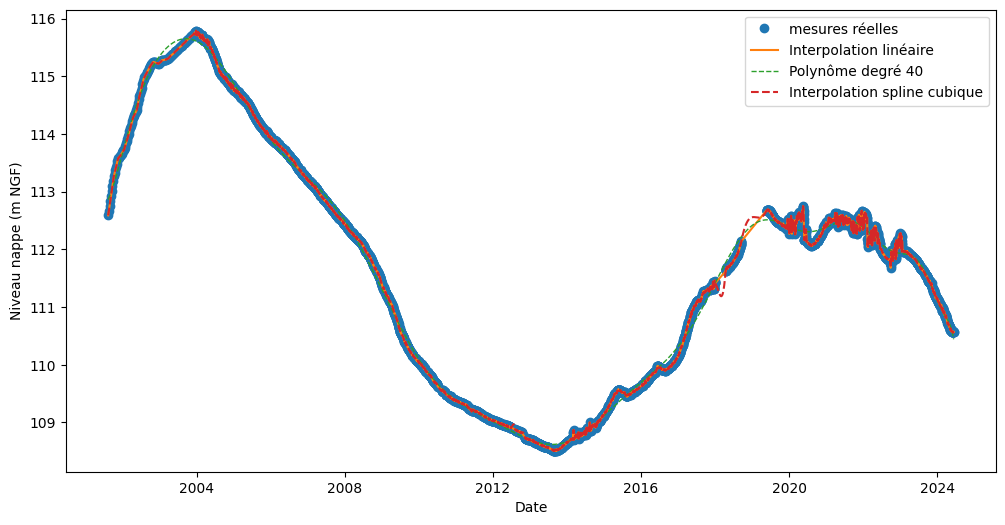

In [38]:
plt.figure(figsize=(12,6))
plt.plot(df['niveau_nappe_eau'], 'o', label='mesures réelles')
plt.plot(df['niveau_interp_linear'], '-', label='Interpolation linéaire')
plt.plot(df['niveau_poly'], '--', label=f'Polynôme degré {n_degree}', linewidth=1)
plt.plot(df['niveau_interp_cubic'], '--', label='Interpolation spline cubique')
plt.xlabel("Date")
plt.ylabel("Niveau nappe (m NGF)")
plt.legend()
plt.show()